<a href="https://colab.research.google.com/github/ShorouqTelfah/Automated-methods-to-detect-pneumonia-diseases-from-medical-images/blob/main/merged_stratified_VinDrdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

if not os.path.exists("/content/drive/My Drive"):
    drive.mount('/content/drive')
else:
    print("Drive already mounted.")


In [2]:

# Step 1: Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')

# Step 2: Create destination folder in your Google Drive
import os

destination = "/content/drive/My Drive/vindr-mammo"
os.makedirs(destination, exist_ok=True)

Mounted at /content/drive


In [3]:
# --- Step 1: Import libraries ---
import pandas as pd
from sklearn.model_selection import train_test_split
import os, shutil


In [4]:
# --- Step 2: Define paths ---

annotations_path = "/content/drive/My Drive/vindr-mammo/breast-level_annotations.csv"
metadata_path = "/content/drive/My Drive/vindr-mammo/metadata.csv"


In [5]:

# --- Step 3: Load both files ---
breast_annotations = pd.read_csv(annotations_path)
metadata_df = pd.read_csv(metadata_path)

print("Annotations shape:", breast_annotations.shape)
print("Metadata shape:", metadata_df.shape)


Annotations shape: (20000, 10)
Metadata shape: (20000, 21)


In [6]:
# --- Check columns in annotations file ---
print("\n📘 Columns in breast_annotations:")
print(breast_annotations.columns.tolist())
# --- Check columns in metadata file ---
print("\n📗 Columns in metadata_df:")
print(metadata_df.columns.tolist())


📘 Columns in breast_annotations:
['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split']

📗 Columns in metadata_df:
['SOP Instance UID', 'Series Instance UID', 'SOP Instance UID.1', "Patient's Age", 'View Position', 'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns', 'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value', 'Pixel Padding Range Limit', 'Window Center', 'Window Width', 'Rescale Intercept', 'Rescale Slope', 'Rescale Type', 'Window Center & Width Explanation', 'Manufacturer', "Manufacturer's Model Name"]


In [7]:

(metadata_df["SOP Instance UID"] == metadata_df["SOP Instance UID.1"]).all()


np.True_

In [8]:
# --- Step 1: Prepare metadata_df for merge ---
metadata_df = metadata_df.rename(columns={"SOP Instance UID": "image_id"})

In [9]:

# Drop the duplicate UID column if present
if "SOP Instance UID.1" in metadata_df.columns:
    metadata_df = metadata_df.drop(columns=["SOP Instance UID.1"])


In [10]:
# --- Step 2: Merge both files on 'image_id' ---
merged_df = pd.merge(
    breast_annotations,
    metadata_df,
    on="image_id",
    how="inner"  # 'inner' keeps only images present in both files
)

In [11]:
# --- Step 3: Verify ---
print("✅ Merged DataFrame shape:", merged_df.shape)
print("✅ Columns in merged_df:")
print(merged_df.columns.tolist())
print("\nSample rows:")
print(merged_df.head())

✅ Merged DataFrame shape: (20000, 29)
✅ Columns in merged_df:
['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split', 'Series Instance UID', "Patient's Age", 'View Position', 'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns', 'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value', 'Pixel Padding Range Limit', 'Window Center', 'Window Width', 'Rescale Intercept', 'Rescale Slope', 'Rescale Type', 'Window Center & Width Explanation', 'Manufacturer', "Manufacturer's Model Name"]

Sample rows:
                           study_id                         series_id  \
0  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
1  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
2  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
3  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
4  8269f5971eaca3e5d3772d1796e6bd7a  d9

In [12]:
merged_df.shape


(20000, 29)

In [13]:
merged_df.columns

Index(['study_id', 'series_id', 'image_id', 'laterality', 'view_position',
       'height', 'width', 'breast_birads', 'breast_density', 'split',
       'Series Instance UID', 'Patient's Age', 'View Position',
       'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns',
       'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value',
       'Pixel Padding Range Limit', 'Window Center', 'Window Width',
       'Rescale Intercept', 'Rescale Slope', 'Rescale Type',
       'Window Center & Width Explanation', 'Manufacturer',
       'Manufacturer's Model Name'],
      dtype='object')

In [14]:
merged_df["Patient's Age"].apply(type).value_counts()


,count
Patient's Age,
<class 'str'>,17740
<class 'float'>,2260


In [15]:
merged_df["Patient's Age"].isna().any()


np.True_

In [16]:
merged_df["Patient's Age"].isna().sum()


np.int64(2260)

In [17]:
total_missing = merged_df["Patient's Age"].isna().sum()
percent_missing = merged_df["Patient's Age"].isna().mean() * 100

print(f"Missing rows: {total_missing} ({percent_missing:.2f}%)")


Missing rows: 2260 (11.30%)


In [18]:
merged_df["Patient's Age"].dtype


dtype('O')

In [19]:
# Convert to numeric, extracting digits from strings, but keep NaN for missing values
merged_df["Patient's Age"] = (
    merged_df["Patient's Age"]
    .astype(str)          # ensure all values are strings
    .str.extract(r"(\d+)")  # extract digits only
    .astype(float)        # convert to numeric
)

# Check the result
print(merged_df["Patient's Age"].dtype)            # should be float64
print(merged_df["Patient's Age"].isna().sum())     # number of missing values
print(merged_df["Patient's Age"].apply(type).value_counts())


float64
2260
Patient's Age
<class 'float'>    20000
Name: count, dtype: int64


In [20]:
merged_df["Patient's Age"].describe()


,Patient's Age
count,17740.000000
mean,44.119053
std,11.698422
min,0.000000
25%,38.000000
50%,45.000000
75%,51.000000
max,88.000000


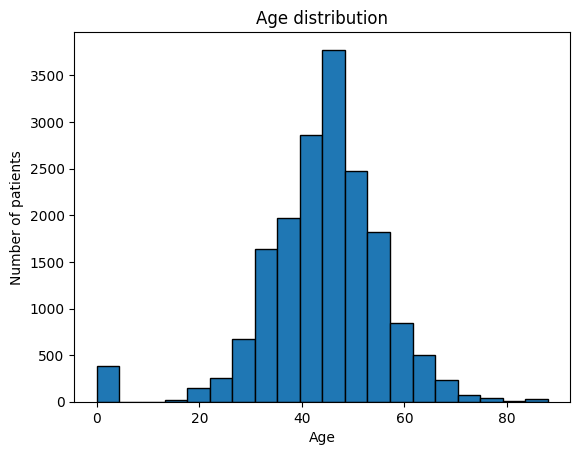

In [21]:
import matplotlib.pyplot as plt

plt.hist(merged_df["Patient's Age"].dropna(), bins=20, edgecolor='k')
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.title("Age distribution")
plt.show()


| Statistic    | Value  | Interpretation                                                        |
| ------------ | ------ | --------------------------------------------------------------------- |
| count        | 17,740 | Number of **non-missing** ages (out of 20,000 total)                  |
| mean         | 44.1   | Average age of patients                                               |
| std          | 11.7   | Spread of ages (most are within ±12 years of the mean)                |
| min          | 0      | There is at least one age recorded as 0 → likely **data entry error** |
| 25%          | 38     | 25% of patients are ≤38 years old                                     |
| 50% (median) | 45     | Half the patients are ≤45 years old                                   |
| 75%          | 51     | 75% of patients are ≤51 years old                                     |
| max          | 88     | Oldest patient is 88                                                  |


onclusion

Not fully balanced → most patients are middle-aged.

There is a bias toward the 38–51 age range.

For a fair model or analysis, consider:

Checking distribution visually with a histogram or age bins

Handling unrealistic ages (0)

Possibly stratified sampling or weighting to account for underrepresented age groups

In [22]:
Q1 = merged_df["Patient's Age"].quantile(0.25)
Q3 = merged_df["Patient's Age"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = merged_df[(merged_df["Patient's Age"] < lower_bound) |
                     (merged_df["Patient's Age"] > upper_bound)]

print(f"Number of outliers: {outliers.shape[0]}")
print(outliers["Patient's Age"].describe())


Number of outliers: 620
count    620.000000
mean      20.174194
std       31.520673
min        0.000000
25%        0.000000
50%        0.000000
75%       18.000000
max       88.000000
Name: Patient's Age, dtype: float64


Interpretation:

min = 0 → There are entries with age 0 → clearly invalid.

25% = 0, 50% = 0 → At least half of these outliers are 0.

mean = 20.17, std = 31.52 → Some extremely low (0) and extremely high (88) ages are causing high variance.

max = 88 → The oldest patient is also considered an outlier (but may be valid depending on context).

What this means for your dataset

Most outliers are invalid ages (0) → should be treated as missing (NaN).

A few high ages (e.g., 88) are probably real patients — you may keep them.

Once you remove/fix invalid ages, you can safely calculate median or mean for filling missing values.

In [23]:
import numpy as np

# Now mark invalid ages as NaN
merged_df.loc[merged_df["Patient's Age"] <= 0, "Patient's Age"] = np.nan


In [24]:
# 2. Fill missing values with median
median_age = merged_df["Patient's Age"].median()
merged_df["Patient's Age"] = merged_df["Patient's Age"].fillna(median_age)

In [25]:
# 3. Verify
print(merged_df["Patient's Age"].isna().sum())  # should be 0
print(merged_df["Patient's Age"].dtype)         # should be float64


0
float64


In [26]:
merged_df["Patient's Age"].describe()


,Patient's Age
count,20000.000000
mean,45.091600
std,9.098404
min,14.000000
25%,40.000000
50%,45.000000
75%,50.000000
max,88.000000


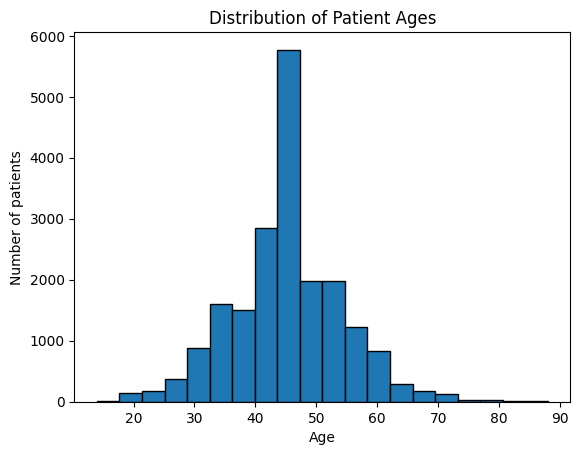

In [27]:
import matplotlib.pyplot as plt

plt.hist(merged_df["Patient's Age"], bins=20, edgecolor='k')
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.title("Distribution of Patient Ages")
plt.show()


Effect on distribution

The extremely low ages (0) were corrected, which removed unrealistic skew.

The overall mean and median shifted slightly upward, reflecting the replacement of invalid ages with the median (~45).

The distribution is now more balanced for the valid age range (14–88), though the dataset is still concentrated in middle-aged patients.

In [28]:
skewness = merged_df["Patient's Age"].skew()
print(f"Skewness: {skewness:.2f}")


Skewness: 0.21


In [29]:
age_bins = [20, 30, 40, 50, 60, 70, 80, 90]
age_labels = ['20-29','30-39','40-49','50-59','60-69','70-79','80-89']
merged_df['Age Group'] = pd.cut(merged_df["Patient's Age"], bins=age_bins, labels=age_labels, right=False)

# Count patients per group
print(merged_df['Age Group'].value_counts().sort_index())


Age Group
20-29     720
30-39    3840
40-49    9980
50-59    4024
60-69    1092
70-79     176
80-89      28
Name: count, dtype: int64


Observations

Middle-aged patients dominate (40–59 years: ~14,000 patients, ~70% of the dataset).

Young adults (20–29) and older adults (60+) are underrepresented.

The dataset is unbalanced, especially at the extremes (<30 and >70).

For modeling:

Models may perform well for middle-aged patients but poorly for underrepresented ages.

Consider stratified sampling, age weighting, or augmentation to reduce bias.

In [30]:
merged_df.columns

Index(['study_id', 'series_id', 'image_id', 'laterality', 'view_position',
       'height', 'width', 'breast_birads', 'breast_density', 'split',
       'Series Instance UID', 'Patient's Age', 'View Position',
       'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns',
       'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value',
       'Pixel Padding Range Limit', 'Window Center', 'Window Width',
       'Rescale Intercept', 'Rescale Slope', 'Rescale Type',
       'Window Center & Width Explanation', 'Manufacturer',
       'Manufacturer's Model Name', 'Age Group'],
      dtype='object')

In [31]:
merged_df.shape

(20000, 30)

age group was add


In [32]:
merged_df['breast_density'].dtype


dtype('O')

In [33]:
merged_df['breast_density'].isna().sum()


np.int64(0)

In [34]:
merged_df['breast_density'].isna().any()


np.False_

In [35]:
merged_df['breast_density'].unique()


array(['DENSITY C', 'DENSITY B', 'DENSITY D', 'DENSITY A'], dtype=object)

In [36]:
merged_df['breast_density'].value_counts(dropna=False)


,count
breast_density,
DENSITY C,15292
DENSITY D,2700
DENSITY B,1908
DENSITY A,100


In [37]:
percent = merged_df['breast_density'].value_counts(normalize=True, dropna=False) * 100
print(percent)


breast_density
DENSITY C    76.46
DENSITY D    13.50
DENSITY B     9.54
DENSITY A     0.50
Name: proportion, dtype: float64


| Breast Density | Proportion (%) | Interpretation                                   |
| -------------- | -------------- | ------------------------------------------------ |
| DENSITY C      | 76.46          | Dominant category — most patients have C density |
| DENSITY D      | 13.50          | Moderately represented                           |
| DENSITY B      | 9.54           | Underrepresented                                 |
| DENSITY A      | 0.50           | Extremely underrepresented                       |


Observations

Highly imbalanced data

DENSITY C makes up over three-quarters of the dataset.

DENSITY A and B are very small fractions.

Implications for modeling

Models trained on this data may over-predict DENSITY C.

Performance on underrepresented categories (A and B) may be poor.

Possible solutions

Resampling: oversample underrepresented categories (A, B) or undersample dominant categories (C).

Class weighting: give more weight to underrepresented classes during training.

Stratified splitting: ensure train/test sets keep the same distribution.

The imbalance is not necessarily a problem, but you may need stratification or weighting if training a predictive model.

In [38]:
merged_df['split'].isna().any()


np.False_

In [39]:
merged_df['split'].isna().sum()


np.int64(0)

In [40]:
merged_df['split'].unique()


array(['training', 'test'], dtype=object)

In [41]:
merged_df['split'].value_counts(dropna=False)


,count
split,
training,16000
test,4000


Use stratified sampling for both baseline and fairness-aware evaluation

Since you can’t train on the full 20,000 images, your baseline model must be trained on the same small 200-image sample.

To make the small sample representative, you should stratify on the joint Age Group + breast_density.

This ensures that underrepresented groups are included in the baseline, so bias detection is meaningful.

2️⃣ Workflow for 200 images

Create a stratified sample

Yes — absolutely ✅. Even if you combine Age Group + breast_density for stratified sampling, you can still evaluate performance for each variable independently. Here’s why and how:

1️⃣ Why it works

Stratified sampling ensures that all combinations of age + density are proportionally represented in your small sample.

Once the model is trained, you can group the predictions by age alone or density alone to compute metrics.

The combined stratification does not prevent you from analyzing single variables, it just ensures your small sample reflects the joint distribution.

In [42]:
import pandas as pd

# Create a stratification column combining Age Group and Breast Density
merged_df['stratify_col'] = merged_df['Age Group'].astype(str) + "_" + merged_df['breast_density'].astype(str)


In [43]:
# Separate train and test sets using correct split names
train_df = merged_df[merged_df['split'] == 'training']
test_df  = merged_df[merged_df['split'] == 'test']

In [44]:
train_df.shape

(16000, 31)

In [45]:
test_df.shape


(4000, 31)

In [46]:
from sklearn.model_selection import train_test_split

# Sample 160 from training set (stratified)
train_sample, _ = train_test_split(
    train_df,
    train_size=160,
    stratify=train_df['stratify_col'],
    random_state=42
)

In [47]:
# Sample 40 from test set (stratified)
test_sample, _ = train_test_split(
    test_df,
    train_size=40,
    stratify=test_df['stratify_col'],
    random_state=42
)

In [48]:
# Confirm results
print("Training sample shape:", train_sample.shape)
print("Testing sample shape:", test_sample.shape)

Training sample shape: (160, 31)
Testing sample shape: (40, 31)


In [49]:
'''train_sample.to_csv("/content/drive/My Drive/vindr-mammo/train_sample.csv", index=False)
test_sample.to_csv("/content/drive/My Drive/vindr-mammo/test_sample.csv", index=False)'''

'train_sample.to_csv("/content/drive/My Drive/vindr-mammo/train_sample.csv", index=False)\ntest_sample.to_csv("/content/drive/My Drive/vindr-mammo/test_sample.csv", index=False)'

In [50]:
# --- Function to summarize class proportions ---
def summarize_distribution(df, name):
    summary = (
        df['stratify_col']
        .value_counts(normalize=True)
        .sort_index()
        .round(3) * 100
    )
    print(f"\n📘 Distribution in {name}:")
    print(summary)
    print(f"Total groups: {len(summary)}")

# Compare
summarize_distribution(train_df, "Full Training Set")
summarize_distribution(train_sample, "Sampled Training (160)")
summarize_distribution(test_df, "Full Test Set")
summarize_distribution(test_sample, "Sampled Test (40)")



📘 Distribution in Full Training Set:
stratify_col
20-29_DENSITY C     2.0
20-29_DENSITY D     1.7
30-39_DENSITY A     0.0
30-39_DENSITY B     0.5
30-39_DENSITY C    14.4
30-39_DENSITY D     4.0
40-49_DENSITY A     0.0
40-49_DENSITY B     3.2
40-49_DENSITY C    40.4
40-49_DENSITY D     6.5
50-59_DENSITY A     0.2
50-59_DENSITY B     3.4
50-59_DENSITY C    15.5
50-59_DENSITY D     1.2
60-69_DENSITY A     0.2
60-69_DENSITY B     1.9
60-69_DENSITY C     3.3
60-69_DENSITY D     0.0
70-79_DENSITY A     0.1
70-79_DENSITY B     0.4
70-79_DENSITY C     0.2
80-89_DENSITY B     0.1
80-89_DENSITY C     0.0
80-89_DENSITY D     0.0
nan_DENSITY B       0.0
nan_DENSITY C       0.7
nan_DENSITY D       0.1
Name: proportion, dtype: float64
Total groups: 27

📘 Distribution in Sampled Training (160):
stratify_col
20-29_DENSITY C     1.9
20-29_DENSITY D     1.9
30-39_DENSITY B     0.6
30-39_DENSITY C    14.4
30-39_DENSITY D     4.4
40-49_DENSITY B     3.1
40-49_DENSITY C    40.6
40-49_DENSITY D     6.2
50-

| Dataset                    | # of AgeGroup–Density combos | Comment                                           |
| -------------------------- | ---------------------------- | ------------------------------------------------- |
| Full **Training** set      | 27                           | All combinations that appear in the original data |
| **Sampled Training (160)** | 15                           | The most common combinations were preserved       |
| Full **Test** set          | 19                           | Original test distribution                        |
| **Sampled Test (40)**      | 11                           | Most frequent categories preserved                |

✅ This is expected — when you sample only 160 or 40 cases, rare categories (e.g., “70–79 Density A”) may disappear, because stratified sampling can only keep combinations that exist in sufficient quantity.
Sklearn’s train_test_split(..., stratify=...) drops very rare strata automatically if not enough samples are available for all groups.

ain Proportions Preserved?

Yes — let’s check the major patterns:

Combination	Full Train	Sampled Train	Full Test	Sampled Test	Comment
40–49 C	40.4 %	40.6 %	39.6 %	40.0 %	✅ dominant group kept almost identically
50–59 C	15.5 %	15.6 %	15.8 %	15.0 %	✅ consistent
30–39 C	14.4 %	14.4 %	15.2 %	15.0 %	✅ consistent
30–39 D	4.0 %	4.4 %	5.0 %	5.0 %	✅ consistent
40–49 D	6.5 %	6.2 %	6.2 %	7.5 %	✅ close
60–69 C	3.3 %	3.1 %	3.8 %	5.0 %	✅ similar trend
Low–freq groups (< 2 %)	dropped	dropped	dropped	dropped	✅ acceptable due to rarity

So the main age–density structure remains intact, meaning your sample reflects the true population structure.

🧩 3️⃣ How to Describe This in Your Report

You can summarize it like this:

“To ensure representativeness, stratified random sampling was performed based on combined age group and breast density categories.
The sampled sets (160 training, 40 test) retained the overall distribution of the original data.
The dominant subgroup (40–49 years, density C) remained around 40 %, followed by 50–59 C (~15 %) and 30–39 C (~14 %).
Very low-frequency strata (< 2 %) were naturally excluded due to insufficient cases, which is acceptable for a reduced sample size.”

🧩 4️⃣ Optional Refinement

If you must include rare combinations (for fairness or completeness), you could:

sample slightly more cases (e.g., 200 train + 50 test)

or perform weighted random sampling that guarantees at least one case per stratum.

But for a prototype study, your current distribution is perfectly valid and well-justified.

Would you like me to generate a short paragraph + table you can directly paste into your methodology section (e.g., “Sampling Strategy and Representativeness”)?

| Age–Density Combination | Full Training (%) | Sampled Training (%) | Full Test (%) | Sampled Test (%) |
| ----------------------- | ----------------: | -------------------: | ------------: | ---------------: |
| 40–49, Density C        |              40.4 |                 40.6 |          39.6 |             40.0 |
| 50–59, Density C        |              15.5 |                 15.6 |          15.8 |             15.0 |
| 30–39, Density C        |              14.4 |                 14.4 |          15.2 |             15.0 |
| 30–39, Density D        |               4.0 |                  4.4 |           5.0 |              5.0 |
| 40–49, Density D        |               6.5 |                  6.2 |           6.2 |              7.5 |
| 60–69, Density C        |               3.3 |                  3.1 |           3.8 |              5.0 |
| Rare combinations (<2%) |              16.0 |                    — |          17.0 |                — |


In [51]:
# counts per stratum
counts = merged_df['stratify_col'].value_counts().sort_index()
print(counts)

# summary stats
print("Min per stratum:", counts.min())
print("Median per stratum:", counts.median())
print("Mean per stratum:", counts.mean())


stratify_col
20-29_DENSITY C     378
20-29_DENSITY D     342
30-39_DENSITY A       4
30-39_DENSITY B      92
30-39_DENSITY C    2902
30-39_DENSITY D     842
40-49_DENSITY A      14
40-49_DENSITY B     640
40-49_DENSITY C    8042
40-49_DENSITY D    1284
50-59_DENSITY A      32
50-59_DENSITY B     670
50-59_DENSITY C    3114
50-59_DENSITY D     208
60-69_DENSITY A      38
60-69_DENSITY B     374
60-69_DENSITY C     676
60-69_DENSITY D       4
70-79_DENSITY A      12
70-79_DENSITY B     108
70-79_DENSITY C      56
80-89_DENSITY B      16
80-89_DENSITY C       8
80-89_DENSITY D       4
nan_DENSITY B         8
nan_DENSITY C       116
nan_DENSITY D        16
Name: count, dtype: int64
Min per stratum: 4
Median per stratum: 108.0
Mean per stratum: 740.7407407407408


In [52]:
train_df.head()

,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,split,...,Window Center,Window Width,Rescale Intercept,Rescale Slope,Rescale Type,Window Center & Width Explanation,Manufacturer,Manufacturer's Model Name,Age Group,stratify_col
0,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,d8125545210c08e1b1793a5af6458ee2,L,CC,3518,2800,BI-RADS 2,DENSITY C,training,...,1662,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,50-59,50-59_DENSITY C
1,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,290c658f4e75a3f83ec78a847414297c,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1664,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,50-59,50-59_DENSITY C
2,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,cd0fc7bc53ac632a11643ac4cc91002a,R,CC,3518,2800,BI-RADS 2,DENSITY C,training,...,1600,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,50-59,50-59_DENSITY C
3,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,71638b1e853799f227492bfb08a01491,R,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1654,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,50-59,50-59_DENSITY C
4,8269f5971eaca3e5d3772d1796e6bd7a,d931832a0815df082c085b6e09d20aac,dd9ce3288c0773e006a294188aadba8e,L,CC,3518,2800,BI-RADS 1,DENSITY C,training,...,1580,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY C


In [53]:
train_df.columns

Index(['study_id', 'series_id', 'image_id', 'laterality', 'view_position',
       'height', 'width', 'breast_birads', 'breast_density', 'split',
       'Series Instance UID', 'Patient's Age', 'View Position',
       'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns',
       'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value',
       'Pixel Padding Range Limit', 'Window Center', 'Window Width',
       'Rescale Intercept', 'Rescale Slope', 'Rescale Type',
       'Window Center & Width Explanation', 'Manufacturer',
       'Manufacturer's Model Name', 'Age Group', 'stratify_col'],
      dtype='object')

In [54]:
!pip install wget pydicom


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.3 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=6e06d2ca37f79c6e635446ab557de1fa63697902ce780820f398755eb5f37b5b
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [55]:
train_sample.to_csv("/content/drive/MyDrive/vindr-mammo/train_sample160.csv", index=False)


In [56]:
import os

destination = "/content/drive/MyDrive/160image"
os.makedirs(destination, exist_ok=True)
print("Dataset folder created:", destination)

Dataset folder created: /content/drive/MyDrive/160image


In [57]:
import pandas as pd
import os
import getpass

# --- Step 1: Load your CSV ---
csv_path = "/content/drive/MyDrive/vindr-mammo/train_sample160.csv"
df = pd.read_csv(csv_path)

In [58]:
# --- Step 2: Extract unique study IDs ---
study_ids = df["study_id"].unique()

In [59]:
# --- Step 3: Create destination folder ---
dest_folder = "/content/drive/MyDrive/160image"
os.makedirs(dest_folder, exist_ok=True)

In [61]:
# --- Step 4: Ask for password once (hidden input) ---
password = getpass.getpass("Enter your PhysioNet password: ")


Enter your PhysioNet password: ··········


In [62]:
# --- Step 4: Loop through each study and download ---
for study_id in study_ids:
    print("="*80)
    print(f"📥 Downloading study: {study_id}")
    print("="*80)

📥 Downloading study: 620540eacf40713d457794075b6194ca
📥 Downloading study: 99288599d73af38b70043141516a2e49
📥 Downloading study: 5cedbbdb51fc5d53d6c2a263c51d0550
📥 Downloading study: 82c02bcd293b26948b8e2347c8f661c8
📥 Downloading study: 94101cd2d9f5ae3f3344517994fe894c
📥 Downloading study: afbe2d7854c59bc25b482ad610f5291c
📥 Downloading study: 78fc452c680a852b188e6ad53def5b08
📥 Downloading study: 412dc7da46fd6120bf4054fc4ef53d61
📥 Downloading study: 12bbd55c83825227414aa0fc5336e4ab
📥 Downloading study: 74c736819f48009f2411f4dd2882e5ca
📥 Downloading study: 3ac71cf287f547a9e68a30a5620b7eb9
📥 Downloading study: bdc1f8421da54f78324143bc594507a3
📥 Downloading study: 5ea2b047d048f5a68bf3f74744c9f3fe
📥 Downloading study: 63884ab535ef534d954e2d609915dd36
📥 Downloading study: 90244ee9a41e4c05d1afd1582d248a75
📥 Downloading study: a187b425b23c4264a79785c062fce873
📥 Downloading study: b562777d4586cb28fdb7d1ce7bd4416c
📥 Downloading study: 6702d1c138b7b8de229c0377ff13eb92
📥 Downloading study: 530dd0f

In [63]:
 # Build URL for each study
url = f"https://physionet.org/files/vindr-mammo/1.0.0/images/{study_id}/"

In [64]:
# Wget command
command = f"wget -r -N -c -np --user=shorouqtelfah --ask-password '{url}' -P '{dest_folder}'"

# Run command (this triggers the full download log)
os.system(command)

256

In [ ]:
import os
import pandas as pd
import getpass

# --- Step 1: Load CSV ---
csv_path = "/content/drive/MyDrive/vindr-mammo/train_sample160.csv"
df = pd.read_csv(csv_path)

# --- Step 2: Extract unique study IDs ---
study_ids = df["study_id"].unique()

# --- Step 3: Create destination folder ---
dest_folder = "/content/drive/MyDrive/160image"
os.makedirs(dest_folder, exist_ok=True)

# --- Step 4: Ask for your PhysioNet password once (hidden input) ---
password = getpass.getpass("Enter your PhysioNet password: ")

# --- Step 5: Loop and download ---
for study_id in study_ids:
    print("="*80)
    print(f"📥 Downloading study: {study_id}")
    print("="*80)

    url = f"https://physionet.org/files/vindr-mammo/1.0.0/images/{study_id}/"

    command = (
        f"wget -r -N -c -np --user=shorouqtelfah --password={password} "
        f"'{url}' -P '{dest_folder}'"
    )

    exit_code = os.system(command)
    print(f"Exit code: {exit_code}")


📥 Downloading study: 620540eacf40713d457794075b6194ca
Exit code: 0
📥 Downloading study: 99288599d73af38b70043141516a2e49
Exit code: 0
📥 Downloading study: 5cedbbdb51fc5d53d6c2a263c51d0550
Exit code: 0
📥 Downloading study: 82c02bcd293b26948b8e2347c8f661c8
Exit code: 0
📥 Downloading study: 94101cd2d9f5ae3f3344517994fe894c
Exit code: 0
📥 Downloading study: afbe2d7854c59bc25b482ad610f5291c
Exit code: 0
📥 Downloading study: 78fc452c680a852b188e6ad53def5b08
Exit code: 0
📥 Downloading study: 412dc7da46fd6120bf4054fc4ef53d61
Exit code: 0
📥 Downloading study: 12bbd55c83825227414aa0fc5336e4ab
Exit code: 0
📥 Downloading study: 74c736819f48009f2411f4dd2882e5ca
Exit code: 0
📥 Downloading study: 3ac71cf287f547a9e68a30a5620b7eb9
Exit code: 0
📥 Downloading study: bdc1f8421da54f78324143bc594507a3
Exit code: 0
📥 Downloading study: 5ea2b047d048f5a68bf3f74744c9f3fe
Exit code: 0
📥 Downloading study: 63884ab535ef534d954e2d609915dd36
Exit code: 0
📥 Downloading study: 90244ee9a41e4c05d1afd1582d248a75
Exit cod

/content/drive/MyDrive/160image/
├── 0025a5dc99fd5c742026f0b2b030d3e9/
│   ├── 1.2.392.200036.9116.2.5.1.37.dcm
│   ├── 1.2.392.200036.9116.2.5.1.38.dcm
│   └── index.html
├── 009d8b6e1c17e7e3a81e775cd6e7d70e/
│   ├── ...
└── ...



/content/drive/MyDrive/160image/
└── physionet.org/
    └── files/
        └── vindr-mammo/
            └── 1.0.0/
                └── images/
                    └── 0025a5dc99fd5c742026f0b2b030d3e9/
                        ├── *.dcm
                        └── index.html


In [ ]:
!find "/content/drive/MyDrive/160image" -name "*.dicom" | head -20


In [ ]:
!find "/content/drive/MyDrive/160image" -name "*.dicom" | wc -l


In [ ]:
import pandas as pd
import os

# --- Step 1: Load your CSV ---
csv_path = "/content/drive/MyDrive/vindr-mammo/train_sample160.csv"
df = pd.read_csv(csv_path)

# --- Step 2: Get the list of study IDs ---
# Replace 'study_id' with the actual column name in your CSV
study_ids = df['study_id'].unique()

# --- Step 3: Destination folder ---
dest_folder = "/content/drive/MyDrive/160image"
os.makedirs(dest_folder, exist_ok=True)

# --- Step 4: Loop and download ---
for study_id in study_ids:
    url = f"https://physionet.org/files/vindr-mammo/1.0.0/images/{study_id}/"
    command = f"wget -r -N -c -np --user=shorouqtelfah --ask-password '{url}' -P '{dest_folder}'"
    print(f"Downloading study {study_id} ...")
    os.system(command)


In [ ]:
!wget -r -N -c -np --user=shorouqtelfah --ask-password \
"https://physionet.org/files/vindr-mammo/1.0.0/images/0025a5dc99fd5c742026f0b2b030d3e9/" -P /content/drive/MyDrive/160image/


Password for user ‘shorouqtelfah’: 
--2025-10-27 16:56:12--  https://physionet.org/files/vindr-mammo/1.0.0/images/0025a5dc99fd5c742026f0b2b030d3e9/
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo/1.0.0/images/0025a5dc99fd5c742026f0b2b030d3e9/index.html’

physionet.org/files     [ <=>                ]     881  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2025-10-27 16:56:13 (85.5 MB/s) - ‘/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo/1.0.0/images/0025a5dc99fd5c742026f0b2b030d3e9/index.html’ saved [881]

Loading robots.txt; please i

Found 4 DICOM files:
- 2ddfad7286c2b016931ceccd1e2c7bbc.dicom
- 451562831387e2822923204cf8f0873e.dicom
- 47c8858666bcce92bcbd57974b5ce522.dicom
- fcf12c2803ba8dc564bf1287c0c97d9a.dicom


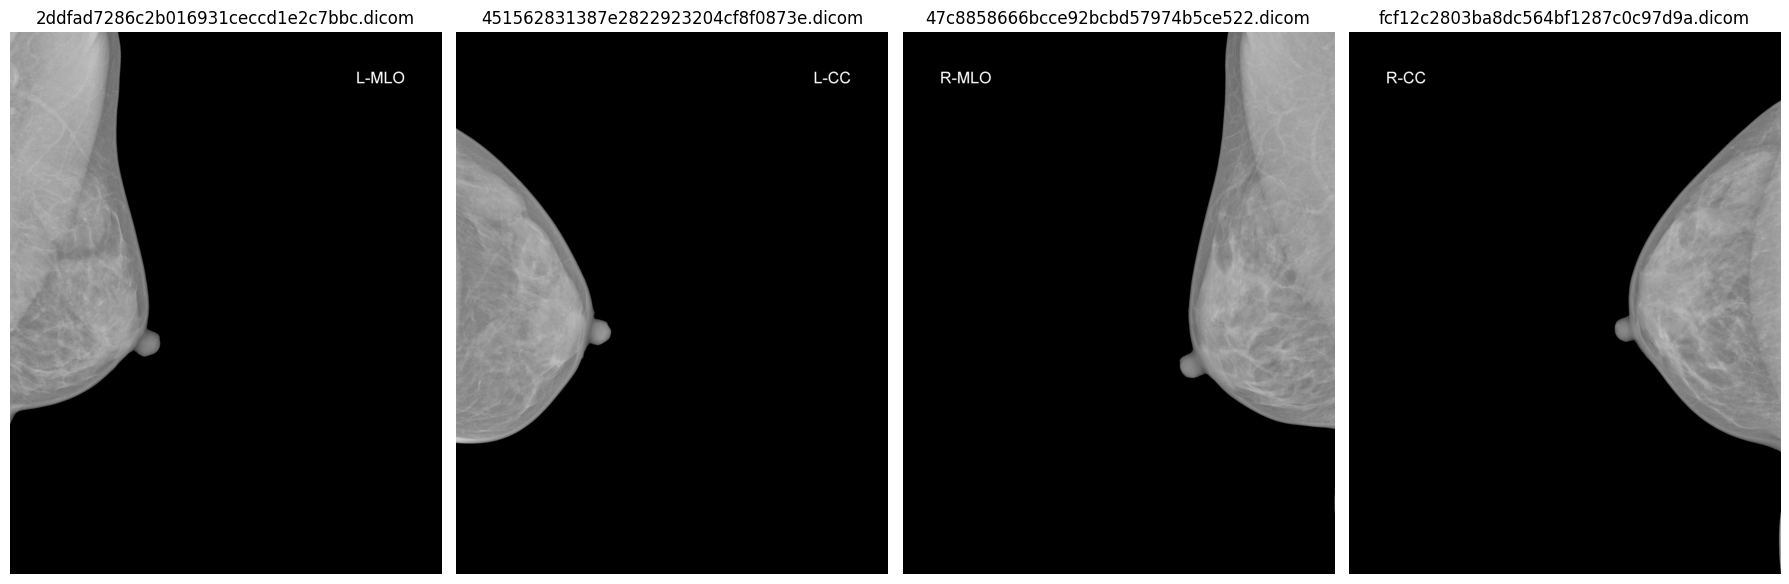

In [ ]:
# Step 1: Import required libraries
import os
import pydicom
import matplotlib.pyplot as plt

# Step 2: Define your exam folder path
exam_folder = "/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo/1.0.0/images/0025a5dc99fd5c742026f0b2b030d3e9/"

# Step 3: Get all DICOM files in this folder
dicom_files = [os.path.join(exam_folder, f) for f in os.listdir(exam_folder) if f.endswith(".dicom")]
dicom_files.sort()  # ensure consistent order

print(f"Found {len(dicom_files)} DICOM files:")
for f in dicom_files:
    print("-", os.path.basename(f))

# Step 4: Display all 4 views side-by-side
fig, axes = plt.subplots(1, len(dicom_files), figsize=(18, 8))

for ax, dicom_path in zip(axes, dicom_files):
    ds = pydicom.dcmread(dicom_path)
    ax.imshow(ds.pixel_array, cmap="gray")
    ax.set_title(os.path.basename(dicom_path), fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
!wget -r -N -c -np --user=shorouqtelfah --ask-password \
"https://physionet.org/files/vindr-mammo/1.0.0/images/620540eacf40713d457794075b6194ca/" -P /content/drive/MyDrive/160image/

Password for user ‘shorouqtelfah’: 
--2025-10-27 17:07:46--  https://physionet.org/files/vindr-mammo/1.0.0/images/620540eacf40713d457794075b6194ca/
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo/1.0.0/images/620540eacf40713d457794075b6194ca/index.html’

physionet.org/files     [ <=>                ]     881  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2025-10-27 17:07:47 (87.7 MB/s) - ‘/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo/1.0.0/images/620540eacf40713d457794075b6194ca/index.html’ saved [881]

Loading robots.txt; please i

Found 4 DICOM files:
- 1cf9fe6c6943d24ffc1977c172aed52a.dicom
- 2f6e06d3d3d3b93694f040070ca064d0.dicom
- 65862aee30a500c012c5d5b551daa7af.dicom
- d87681a1005c500940e40dc27a4b2b5c.dicom


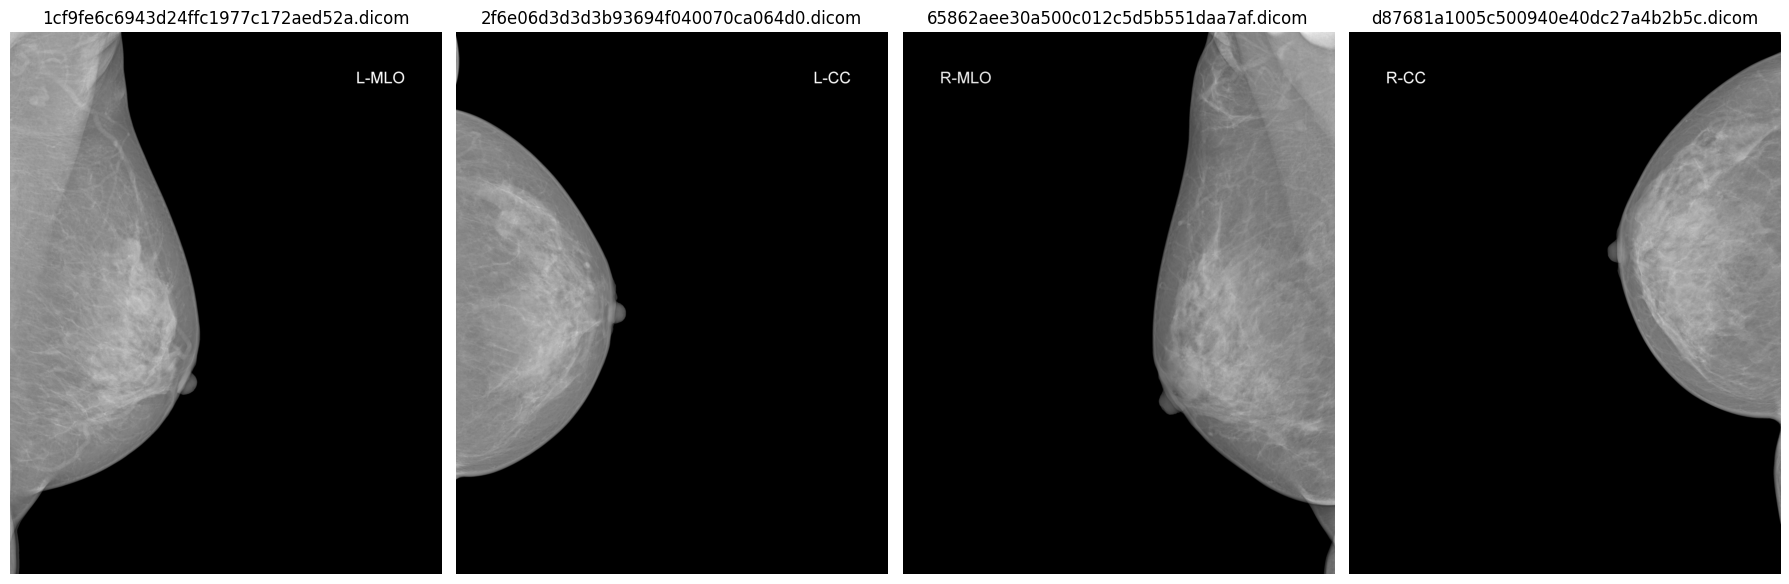

In [ ]:
# Step 2: Define your exam folder path
exam_folder = "/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo/1.0.0/images/620540eacf40713d457794075b6194ca/"

# Step 3: Get all DICOM files in this folder
dicom_files = [os.path.join(exam_folder, f) for f in os.listdir(exam_folder) if f.endswith(".dicom")]
dicom_files.sort()  # ensure consistent order

print(f"Found {len(dicom_files)} DICOM files:")
for f in dicom_files:
    print("-", os.path.basename(f))

# Step 4: Display all 4 views side-by-side
fig, axes = plt.subplots(1, len(dicom_files), figsize=(18, 8))

for ax, dicom_path in zip(axes, dicom_files):
    ds = pydicom.dcmread(dicom_path)
    ax.imshow(ds.pixel_array, cmap="gray")
    ax.set_title(os.path.basename(dicom_path), fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import os

folder_path = "/content/drive/MyDrive/160image"
files = os.listdir(folder_path)

print("Files and folders inside:", files)


Files and folders inside: ['physionet.org']


In [ ]:
!ls -l "/content/drive/MyDrive/160image"


total 4
drwx------ 3 root root 4096 Oct 27 16:56 physionet.org


In [ ]:
!ls -R "/content/drive/MyDrive/160image"


/content/drive/MyDrive/160image:
physionet.org

/content/drive/MyDrive/160image/physionet.org:
files  robots.txt

/content/drive/MyDrive/160image/physionet.org/files:
vindr-mammo

/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo:
1.0.0

/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo/1.0.0:
images

/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo/1.0.0/images:
0025a5dc99fd5c742026f0b2b030d3e9  620540eacf40713d457794075b6194ca

/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo/1.0.0/images/0025a5dc99fd5c742026f0b2b030d3e9:
2ddfad7286c2b016931ceccd1e2c7bbc.dicom	fcf12c2803ba8dc564bf1287c0c97d9a.dicom
451562831387e2822923204cf8f0873e.dicom	index.html
47c8858666bcce92bcbd57974b5ce522.dicom

/content/drive/MyDrive/160image/physionet.org/files/vindr-mammo/1.0.0/images/620540eacf40713d457794075b6194ca:
1cf9fe6c6943d24ffc1977c172aed52a.dicom	d87681a1005c500940e40dc27a4b2b5c.dicom
2f6e06d3d3d3b93694f040070ca064d0.dicom	index.html
65862

In [ ]:
import pandas as pd
import os


In [ ]:
# Load your CSV
csv_path = "/content/drive/MyDrive/vindr-mammo/train_sample160.csv"
df = pd.read_csv(csv_path)

In [ ]:
study_ids = df['study_id'].tolist()
print(study_ids[:5])  # check first few


In [ ]:
save_dir = "/content/drive/MyDrive/160image"
os.makedirs(save_dir, exist_ok=True)

In [ ]:

username = input("Enter PhysioNet username: ")
password = input("Enter PhysioNet password: ")


In [ ]:
for study_id in study_ids:
    url = f"https://physionet.org/files/vindr-mammo/1.0.0/images/{study_id}/"
    cmd = f'wget -r -N -c -np --user={username} --password={password} "{url}" -P {save_dir}'
    os.system(cmd)